In [1]:
import h5py
import numpy as np
from scipy import signal, ndimage
import sys
import os
import tifffile
import matplotlib.pyplot as plt 
sys.path.append(os.path.abspath("../src"))

In [2]:
from alignment import CrossCorrelationAlignment, TomoConsistencyAlignment, TomoConsistencyConfig, VerticalAlignment, VerticalAlignmentConfig
import utilities as utils

No module named 'tomopy.recon'
No module named 'recast_tomo'


hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


#### Load data

In [3]:
folder = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/'
file = folder + '/scan_275019_275199_tomo_complex.nxs' 

with h5py.File(file,'r') as f:
    f.visititems(utils.io_tools.print_keys)

entry1 <class 'h5py._hl.group.Group'>
entry1/definition <class 'h5py._hl.dataset.Dataset'>
entry1/instrument <class 'h5py._hl.group.Group'>
entry1/instrument/detector <class 'h5py._hl.group.Group'>
entry1/instrument/detector/data <class 'h5py._hl.dataset.Dataset'>
entry1/instrument/detector/image_key <class 'h5py._hl.dataset.Dataset'>
entry1/sample <class 'h5py._hl.group.Group'>
entry1/sample/name <class 'h5py._hl.dataset.Dataset'>
entry1/sample/rotation_angle <class 'h5py._hl.dataset.Dataset'>


In [4]:
# you can find the data_key and angle_key values in the printed statements above. 
# You can also find them by opening the dataset in DAWN (which is probably a bit easier)
# "ax_order" refers to the order of the axes in the data file, 
# e.g. for a scan with projection size 100*200 (X*Y) and 181 angles, if the file has shape 100*200*181, 
# ax_order should be ["x", "y", "angle"]. If the file has shape 181*200*100, ax_order should be ["angle", "y", "x"]
img, theta, _ = utils.io_tools.load_data(file, 
                                         data_key= '/entry1/instrument/detector/data', 
                                         angle_key = '/entry1/sample/rotation_angle',
                                         y_idx=[0,None,1], x_idx=[0,None,1], angle_idx=[0,None,1], 
                                         ax_order = ['angle', 'y', 'x'])

raw data shape: (181, 582, 740)
projections shape: (181, 582, 740)
angles shape: (181,)


Here we remove any bad or duplicate angles. TO DO: replace with code to automatically find the angles to remove

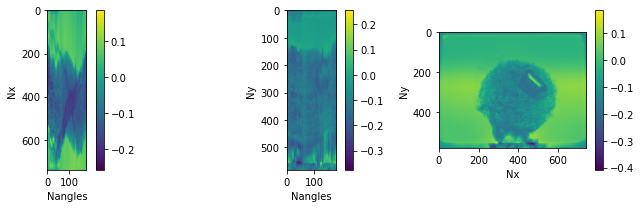

In [5]:
# remove bad angles
bad_projs = [] # for the example dataset

good_projs = np.ones(theta.shape[0], dtype=bool)
good_projs[bad_projs] = 0

img = img[:,:,good_projs] 
theta = theta[good_projs]

utils.display_tools.plot_3axes(img.real, array_name='', data_order=['Ny', 'Nx','Nangles'])


Next choose a range to crop in vertical (Ny) and horizontal (Nx)

In [6]:
[Ny, Nx, Nangles] = img.shape
Ny_start = 83
Ny_stop = Ny-Ny_start

Nx_start = 66
Nx_stop = Nx-Nx_start

utils.display_tools.plot_crop(img.real, Nx_start, Nx_stop, Ny_start, Ny_stop, Nangles)

interactive(children=(IntSlider(value=90, description='slice_idx', max=180), Output()), _dom_classes=('widget-…

#### Quick cross-correlation alignment

(Work in progress) This could be replaced with a different method

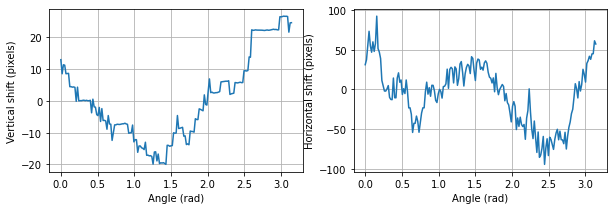

In [7]:
xcorr = CrossCorrelationAlignment()
shift_correlation = xcorr.run_alignment(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], theta)

If we're satisfied with the alignment save the calculated values to the total_shifts array. 

We can choose to apply the shifts we found to only horizontal OR both

In [8]:
shift_total = np.zeros((Nangles,2))

In [9]:
shift_total[:,0] = shift_total[:,0] + shift_correlation[:,0] # only apply horizontal
#shift_total = shift_total + shift_correlation # apply both

Apply cross-correlation shift to the original image

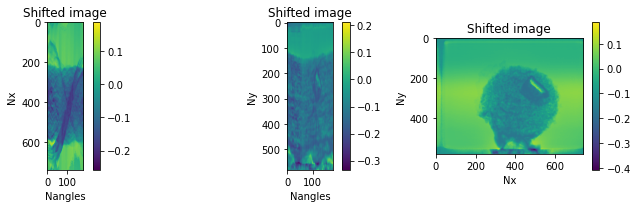

In [10]:
for m in range(shift_total.shape[0]):
    img[:,:,m] = np.roll(img[:,:,m],(int(shift_total[m,0]), int(shift_total[m,1])),axis=(1,0)) 
utils.display_tools.plot_3axes(img.real, 'Shifted image', ['Ny', 'Nx', 'Nangles'])

#### Vertical alignment

First we do a 2D phase unwrapping - this requires complex data so if we do not have complex data, skip the unwrapping step and try the vertical alignment directly on the image

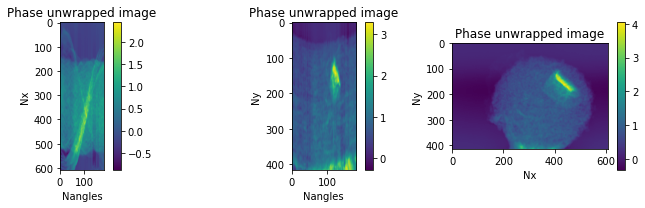

In [11]:
unwrap = '2d' # '1d'
if unwrap == '2d':
    phase, residuals = utils.phase_tools.unwrap2D_fft2(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], empty_region=[10,10])
elif unwrap == '1d':
    phase, phase_diff, residuals = utils.phase_tools.unwrap2D_fft(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], 0, boundary=None, step=0)
    
phase=phase.real

utils.display_tools.plot_3axes(phase, 'Phase unwrapped image', ['Ny','Nx','Nangles'])

Run the vertical mass alignment code. It first runs a quick cross-correlation estimate and then uses vertical mass fluctuation to iteratively improve on the result. 

Here we run the code with default config values but they can be edited by redefining any variable as shown below.

In [12]:
config = VerticalAlignmentConfig(
    data_filter = 0.01,
    iterations = 1000) # over-ride defaults here if needed
va = VerticalAlignment(config)
shift_vertical = va.run_alignment(phase, residuals, theta)

SystemError: <class 'numpy.linalg.LinAlgError'> returned a result with an exception set

If we're satisfied with the alignment, save the calculated values to the total_shifts array. 

Here we only apply shifts to the vertical

In [17]:
shift_total[:,1] = shift_total[:,1] + shift_vertical

NameError: name 'shift_vertical' is not defined

Apply shift to the original image

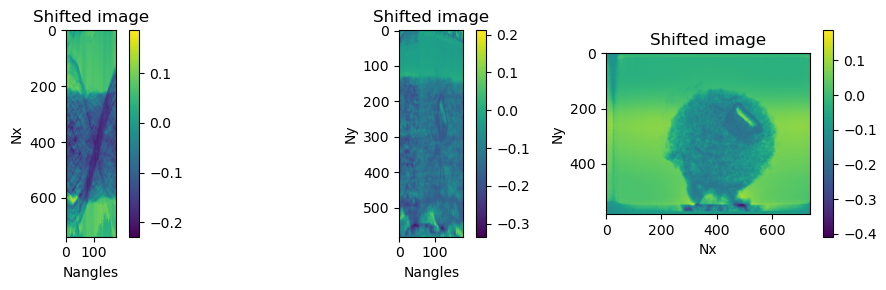

In [17]:
for m in range(shift_total.shape[0]):
    # uncomment the line below if you want to apply the x-correlation + vertical mass shift 
    # img[:,:,m] = np.roll(img[:,:,m],(int(shift_total[m,0]), int(shift_total[m,1])),axis=(1,0)) 

    # uncomment the line below if you only want to apply the vertical shift
    img[:,:,m] = np.roll(img[:,:,m],int(shift_vertical[m]),axis=(0)) 
    
utils.display_tools.plot_3axes(img.real, 'Shifted image', ['Ny', 'Nx', 'Nangles'])

#### Tomoconsistency alignment

First get the phase gradient and calculate weights

In [18]:
# get the phase gradient
img_grad = utils.phase_tools.get_phase_gradient_1D(img, ax=1)[Ny_start:Ny_stop,Nx_start:Nx_stop,:] # apply on the full image then re-crop
[Ny, Nx, Nangles] = img_grad.shape

high_pass_filter = 0.01
# include the effect of high pass filter into the weights 
size = np.maximum(3, int(np.ceil(high_pass_filter * Nx)))
gauss_window = signal.windows.gaussian(size, std = size/6)
hanning_window = signal.windows.hann(3)
ker = gauss_window.reshape(-1,1) * hanning_window

# relevance weights -> remove effect of potential residues / phase jumps 
ker2 = ker[np.newaxis,:,:]
convolution_result = ndimage.convolve((np.abs(img_grad) > 2).astype(np.float32), ker2.astype(np.float32), mode = 'constant', cval = 0.0)
weights_find_shift = np.maximum(0,1-convolution_result)

get_phase_gradient_1D: img shape after padding: (598, 740, 181)
get_phase_gradient_1D: img shape after smoothing: (598, 740, 181)
get_phase_gradient_1D: d_img shape before removing padding: (598, 740, 181)
tuple[ind(ind)]: (slice(8, 590, None), slice(None, None, None), slice(None, None, None))
get_phase_gradient_1D: d_img shape after removing padding: (582, 740, 181)


We can further reduce the vertical range here if needed

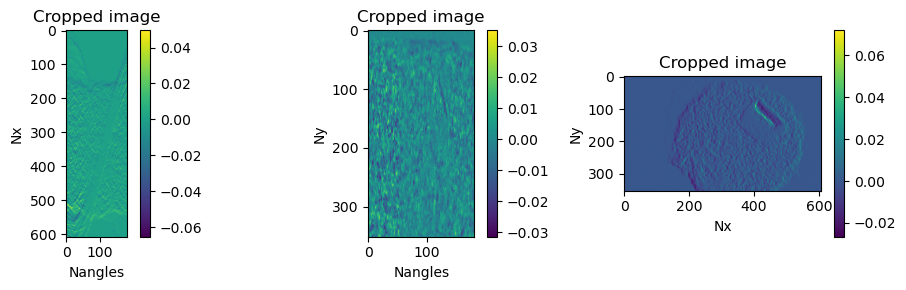

In [19]:
vert_range = (31, Ny-33)

utils.display_tools.plot_3axes(img_grad.real[vert_range[0]:vert_range[1],:,:], 'Cropped image', ['Ny', 'Nx', 'Nangles'])

ROI = (
    slice(int(vert_range[0]), int(vert_range[1])),
    slice(None)
)

Setup the alignment code with default values

In [20]:
config = TomoConsistencyConfig(
    max_iterations = 200,
    step_relaxation = 0.5,
    high_pass_filter = 0.01,
    min_step_size = 0.01,
    unwrap_axis = 2,
    unwrap_data_method = 'fft_1d',
    plot_interactive = True,
    center_reconstruction = True,
    apply_mask = False,
    momentum_acceleration = True,
    align_horizontal = True,
    align_vertical = False,
    apply_positivity = True)

aligner = TomoConsistencyAlignment(config)


Run the TomoConsistency code with different binning levels

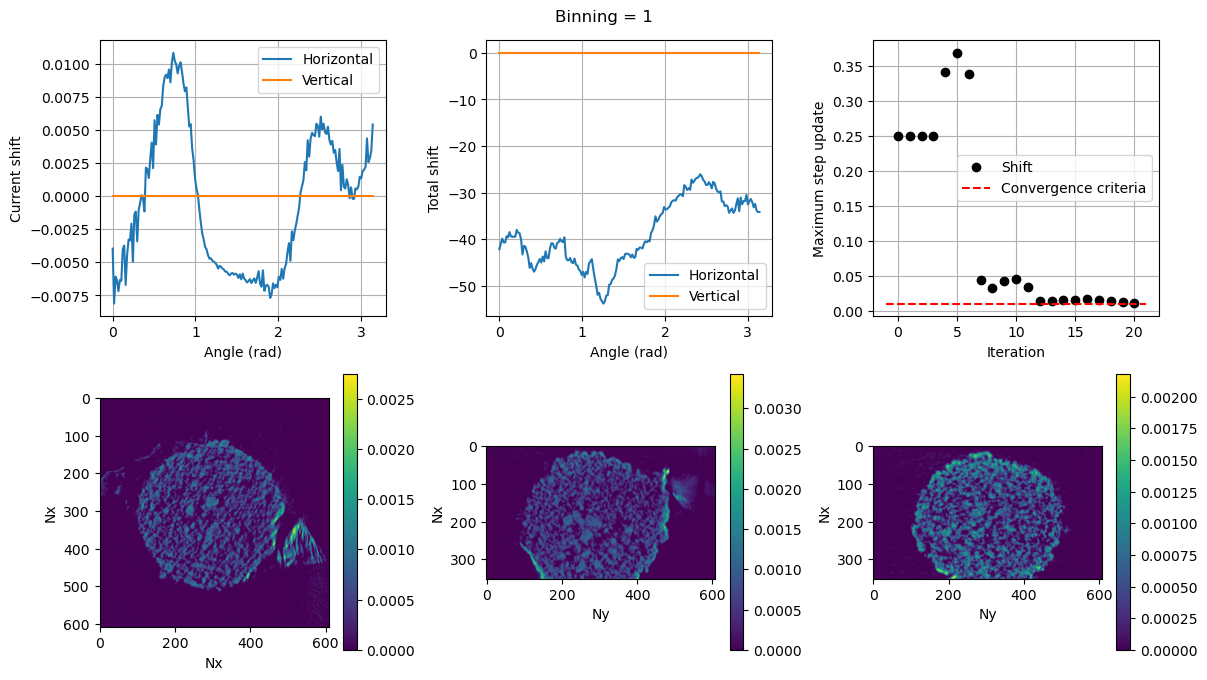

Total time: 10.72 minuteseconds


In [21]:
import time
t0 = time.time()

# Loop over different binning levels
bin_levels = [8, 4, 2, 1] 

shift_tomoconsistency = np.zeros((Nangles,2))
for binning in bin_levels:

    # Apply ROI and binning
    sinogram = utils.shift_tools.imshift_generic(img_grad, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = ROI, downsample = binning, interp_method = 'fft', interp_sign = 1)
    

    weights_find_shift = np.maximum(0,1-convolution_result)
    weights_find_shift = utils.shift_tools.imshift_generic(weights_find_shift, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 0, 
                                        ROI = ROI, downsample = binning, interp_method = 'linear', interp_sign = 1)
    
    shift_tomoconsistency, _, rec, _ = aligner.run_alignment(sinogram, theta, weights_find_shift, shift_tomoconsistency, binning)

print(f'\rTotal time: {(time.time() - t0)/60:.2f} minutes')

In [22]:
#shift_total[:,0] = shift_total[:,0] + shift_tomoconsistency[:,0] # only apply horizontal
shift_total = shift_total + shift_tomoconsistency # apply both

#### Perform the reconstruction ourselves

We can plot the reconstruction again

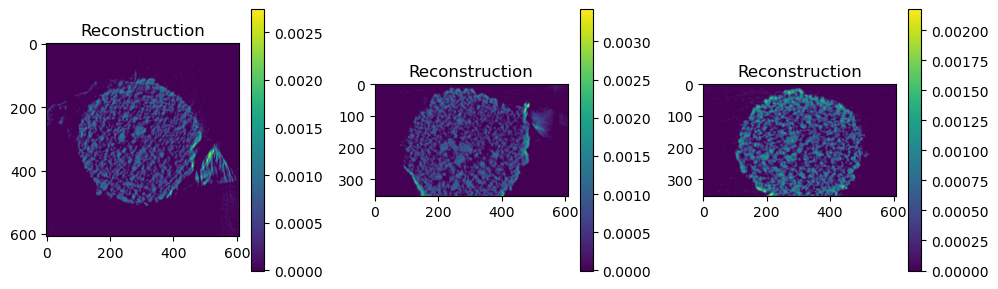

In [23]:
utils.display_tools.plot_3axes(rec, 'Reconstruction')

Or run the reconstruction directly using the shifts we found from the alignment:
- Apply shifts and whatever binning or ROI we want, or just reconstruct everything
- Apply phase unwrapping
- Run the reconstruction
- Apply a circular mask and remove negative values

unwrap2D_fft: phase_diff shape: (416, 181, 608)
unwrap2D_fft: phase shape: (416, 181, 608)


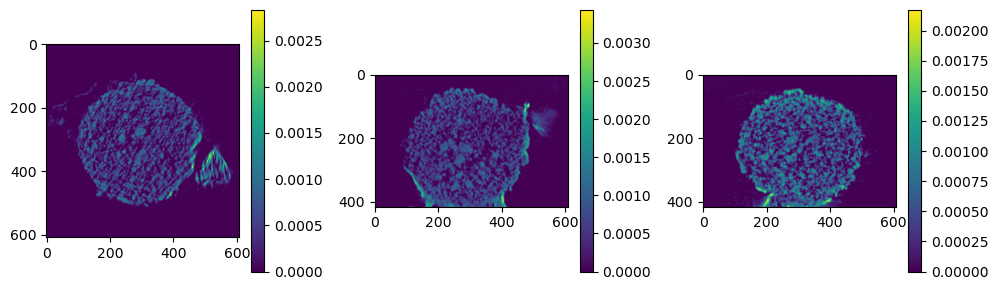

In [25]:
# bin or apply ROI or use full data
# img_grad = utils.phase.get_phase_gradient_1D(img, ax=1) # re-run phase gradient calculation if you want to skip the initial cropping as well 

sinogram = utils.shift_tools.imshift_generic(img_grad, shift=shift_tomoconsistency, Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = None, downsample = 1, interp_method = 'fft', interp_sign = 1) # can include ROI here too

import astra                                
# transpose for astra
sinogram = sinogram.transpose((0, 2, 1))
[Ny, Nangles, Nx] = sinogram.shape

# apply phase unwrapping
phase = -utils.phase_tools.unwrap2D_fft(sinogram, axis=2, boundary=None)[0]

# run reconstruction
dtheta = (theta[-1] - theta[0]) / (len(theta) - 1) if len(theta) > 1 else 1.0
weights_fbp = np.full(len(theta), dtheta, dtype=np.float32)

vol_geom, proj_geom = utils.recon_tools.init_astra(Nx, Ny, theta)
rec = utils.recon_tools.FBP_astra(phase, vol_geom, proj_geom, weights_fbp)

# apply circular mask
rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

# remove negative values
rec = np.maximum(0, rec)

utils.display_tools.plot_3axes(rec)

#### Fourier ring correlation

Get two reconstructions for the Fourier ring correlation. Split data and run reconstruction

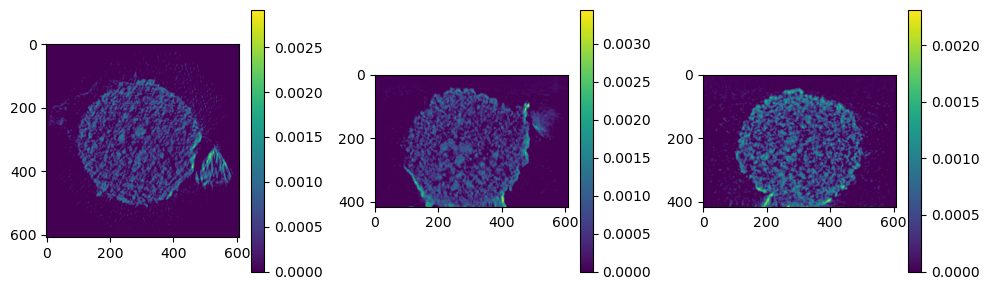

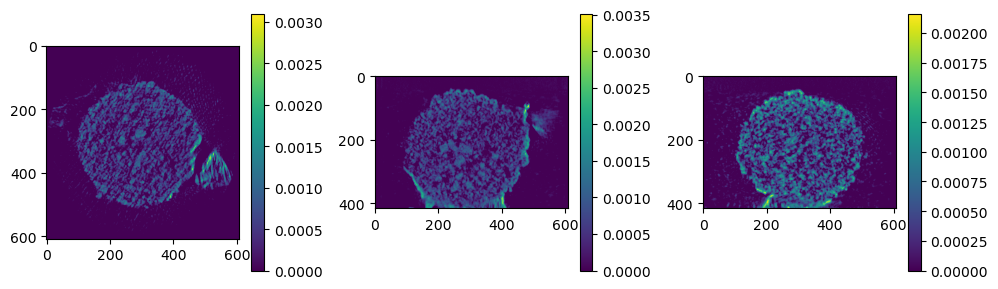

In [26]:
rec_list = []
for i in range(2):
    sinogram_half = phase[:, i::2, :]
    theta_half = theta[i::2]

    [Ny, Nangles, Nx] = sinogram_half.shape

    # run reconstruction
    dtheta = (theta_half[-1] - theta_half[0]) / (len(theta_half) - 1) if len(theta_half) > 1 else 1.0
    weights_fbp = np.full(len(theta_half), dtheta, dtype=np.float32)

    Nz = Nx
    vol_geom = astra.create_vol_geom(Nx, Nz, Ny)

    # Projection geometry (3D parallel beam)
    proj_geom = astra.create_proj_geom(
        'parallel3d',
        1,  # detector pixel size in x
        1,  # detector pixel size in y   
        Ny,          
        Nx,          
        theta_half
    )

    rec = utils.recon_tools.FBP_astra(sinogram_half, vol_geom, proj_geom, weights_fbp)

    # apply circular mask
    rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

    # remove negative values
    rec = np.maximum(0, rec)

    rec_list.append(rec)
utils.display_tools.plot_3axes(rec_list[0])
utils.display_tools.plot_3axes(rec_list[1])

Run 2D Fourier ring correlation

Spatial resolution is roughly  68.83018867924527  -  138.1818181818182  nm.


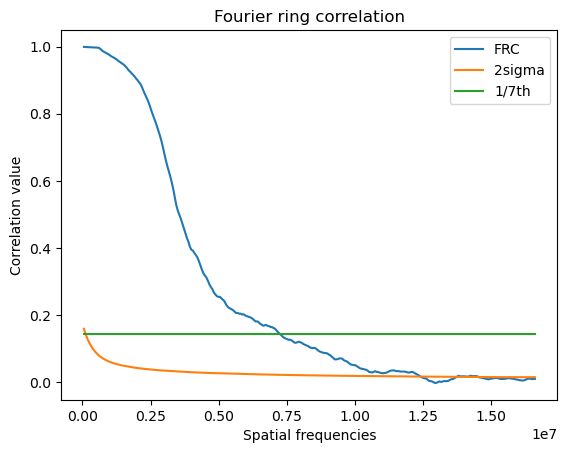

In [27]:
utils.quality_metrics.fourier_ring_correlation(rec_list[0][rec_list[0].shape[0]//2,:,:], rec_list[1][rec_list[1].shape[0]//2,:,:])

#### Save

Uncomment below to save the shifts as csv and the reconstruction as a tiff stack

In [ ]:
# np.savetxt('shift_total.csv', shift_total, delimiter=',', header='horizontal,vertical', comments='')

In [35]:
# save_dir = 'reconstruction'
# os.makedirs(save_dir, exist_ok=True)

# for i in range(rec.shape[0]):
#    tifffile.imwrite(os.path.join(save_dir, f'slice_{i:04d}.tif'), rec[i])

#### Debug

In [36]:
# comparison with matlab (if you have those values)
#vertical_shifts = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/vmf.txt' 
#horizontal_shifts = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/crosscorrelation.txt'
#tomoconsistency_shifts = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/tomoconsistency.txt'

#debug_shifts = np.zeros((theta.shape[0],2))
#debug_shifts[1:,0] = np.loadtxt(horizontal_shifts, delimiter=',')[:,0] + np.loadtxt(tomoconsistency_shifts,delimiter=',')[:,0]
#debug_shifts[1:,1] = np.loadtxt(vertical_shifts, delimiter=',')

#plt.figure(figsize=[10,3])
#plt.subplot(121),plt.plot(theta, shift_total[:,1], label='Python')
#plt.subplot(121),plt.plot(theta, debug_shifts[:,1], '--', label='MATLAB code') 
#plt.ylabel('Vertical shift (pixels)'), plt.xlabel('Angle (rad)')
#plt.subplot(122),plt.plot(theta, shift_total[:,0], label='Python')
#plt.subplot(122),plt.plot(theta, debug_shifts[:,0], '--', label='MATLAB code')
#plt.ylabel('Horizontal shift (pixels)'), plt.xlabel('Angle (rad)')
#plt.legend()